## TASK 0NE

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the Netflix dataset
netflix_path = r"C:\SQL PROJECTS\DATALAB_INTERN\netflix_titles.csv"
netflix_df = pd.read_csv(netflix_path)

In [3]:
# Display the first few rows
print("First 5 rows of the Netflix dataset:")
print(netflix_df.head())

First 5 rows of the Netflix dataset:
  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Sea

In [4]:
# Display dataset information
print("\n" + "="*50)
print("DATASET INFORMATION")
print("="*50)

# 1. Dataset shape
print(f"\nNumber of rows: {netflix_df.shape[0]}")
print(f"Number of columns: {netflix_df.shape[1]}")

# 2. Data types of all columns
print("\n" + "-"*50)
print("DATA TYPES:")
print("-"*50)
print(netflix_df.dtypes)

# 3. Identify numerical and categorical features
print("\n" + "-"*50)
print("FEATURE TYPES:")
print("-"*50)

numerical_features = netflix_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = netflix_df.select_dtypes(include=['object']).columns.tolist()

print(f"\nNumerical features ({len(numerical_features)}): {numerical_features}")
print(f"\nCategorical features ({len(categorical_features)}): {categorical_features}")

# 4. Check for unique identifiers
print("\n" + "-"*50)
print("UNIQUE IDENTIFIERS:")
print("-"*50)
print(f"show_id unique count: {netflix_df['show_id'].nunique()}")
print(f"title unique count: {netflix_df['title'].nunique()}")
print(f"show_id is unique: {netflix_df['show_id'].nunique() == len(netflix_df)}")

# 5. Dataset description
print("\n" + "-"*50)
print("DATASET DESCRIPTION:")
print("-"*50)
print("\nThis dataset contains information about movies and TV shows available on Netflix.")
print("It includes details such as:")
print("- Type (Movie or TV Show)")
print("- Title, Director, Cast")
print("- Country of production")
print("- Date added to Netflix")
print("- Release year")
print("- Rating (content rating)")
print("- Duration (minutes for movies, seasons for TV shows)")
print("- Genre/Category (listed_in)")
print("- Description")


DATASET INFORMATION

Number of rows: 8807
Number of columns: 12

--------------------------------------------------
DATA TYPES:
--------------------------------------------------
show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

--------------------------------------------------
FEATURE TYPES:
--------------------------------------------------

Numerical features (1): ['release_year']

Categorical features (11): ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'rating', 'duration', 'listed_in', 'description']

--------------------------------------------------
UNIQUE IDENTIFIERS:
--------------------------------------------------
show_id unique count: 8807
title unique count: 8807
show_id is unique: True

------------------

## TASK TWO

In [5]:
# Check for missing values
print("="*50)
print("MISSING VALUES ANALYSIS")
print("="*50)

# Count missing values per column
missing_values = netflix_df.isnull().sum()
missing_percentage = (netflix_df.isnull().sum() / len(netflix_df)) * 100

# Create a summary DataFrame
missing_summary = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_percentage.round(2)
})
missing_summary = missing_summary[missing_summary['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

print("\nColumns with missing values:")
print(missing_summary)

# Show total missing values
print(f"\nTotal missing values: {netflix_df.isnull().sum().sum()}")

MISSING VALUES ANALYSIS

Columns with missing values:
            Missing Count  Missing Percentage
director             2634               29.91
country               831                9.44
cast                  825                9.37
date_added             10                0.11
rating                  4                0.05
duration                3                0.03

Total missing values: 4307


In [6]:
# Create a copy for cleaning
netflix_clean = netflix_df.copy()

print("="*50)
print("HANDLING MISSING VALUES")
print("="*50)

# 1. Fill missing directors with 'Unknown'
netflix_clean['director'] = netflix_clean['director'].fillna('Unknown')
print(f"✓ Filled missing 'director' values with 'Unknown'")

# 2. Fill missing cast with 'Unknown'
netflix_clean['cast'] = netflix_clean['cast'].fillna('Unknown')
print(f"✓ Filled missing 'cast' values with 'Unknown'")

# 3. Fill missing country with 'Unknown'
netflix_clean['country'] = netflix_clean['country'].fillna('Unknown')
print(f"✓ Filled missing 'country' values with 'Unknown'")

# 4. Fill missing rating with 'Not Rated'
netflix_clean['rating'] = netflix_clean['rating'].fillna('Not Rated')
print(f"✓ Filled missing 'rating' values with 'Not Rated'")

# 5. For date_added, we'll fill missing with 'Unknown'
netflix_clean['date_added'] = netflix_clean['date_added'].fillna('Unknown')
print(f"✓ Filled missing 'date_added' values with 'Unknown'")

# Verify missing values are handled
print("\n" + "-"*50)
print("MISSING VALUES AFTER HANDLING:")
print("-"*50)
print(netflix_clean.isnull().sum())

HANDLING MISSING VALUES
✓ Filled missing 'director' values with 'Unknown'
✓ Filled missing 'cast' values with 'Unknown'
✓ Filled missing 'country' values with 'Unknown'
✓ Filled missing 'rating' values with 'Not Rated'
✓ Filled missing 'date_added' values with 'Unknown'

--------------------------------------------------
MISSING VALUES AFTER HANDLING:
--------------------------------------------------
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        3
listed_in       0
description     0
dtype: int64


In [7]:
# Check for duplicates
print("="*50)
print("DUPLICATE RECORDS CHECK")
print("="*50)

# Check exact duplicates
duplicates = netflix_clean.duplicated()
duplicate_count = duplicates.sum()
print(f"\nNumber of duplicate rows: {duplicate_count}")

# Check duplicates based on title (potential duplicate titles)
title_duplicates = netflix_clean['title'].duplicated().sum()
print(f"Number of duplicate titles: {title_duplicates}")

# Show duplicate titles if any
if title_duplicates > 0:
    duplicate_titles = netflix_clean[netflix_clean['title'].duplicated(keep=False)]['title'].unique()
    print(f"\nDuplicate titles found (showing first 5): {duplicate_titles[:5]}")

# Remove exact duplicates
if duplicate_count > 0:
    netflix_clean = netflix_clean.drop_duplicates()
    print(f"\n✓ Removed {duplicate_count} duplicate rows")
else:
    print("\n✓ No exact duplicate rows found")

DUPLICATE RECORDS CHECK

Number of duplicate rows: 0
Number of duplicate titles: 0

✓ No exact duplicate rows found


In [10]:
print("="*50)
print("STANDARDIZATION")
print("="*50)

# First, let's check the duration column for NaN values
print("\nChecking duration column...")
print(f"Duration column has {netflix_clean['duration'].isna().sum()} NaN values")

# Convert duration to string first, handling NaN
netflix_clean['duration'] = netflix_clean['duration'].fillna('Unknown')
netflix_clean['duration'] = netflix_clean['duration'].astype(str)

# Now split duration into numeric and unit
def split_duration(duration):
    if duration == 'Unknown' or duration == 'nan':
        return None, None
    parts = duration.split()
    if len(parts) >= 2:
        try:
            return int(parts[0]), parts[1]
        except:
            return None, None
    return None, None

netflix_clean['duration_num'] = netflix_clean['duration'].apply(lambda x: split_duration(x)[0])
netflix_clean['duration_unit'] = netflix_clean['duration'].apply(lambda x: split_duration(x)[1])

print(f"   ✓ Split 'duration' into numeric and unit columns")

# 1. Convert date_added to datetime format
print("\n1. Converting date_added to datetime format...")
netflix_clean['date_added_dt'] = pd.to_datetime(netflix_clean['date_added'], errors='coerce')
print(f"   ✓ Successfully converted date_added to datetime")

# 2. Extract month and year from date_added
netflix_clean['add_month'] = netflix_clean['date_added_dt'].dt.month
netflix_clean['add_year'] = netflix_clean['date_added_dt'].dt.year
print(f"   ✓ Extracted month and year from date_added")

# 3. Standardize text formatting - convert type to consistent case
netflix_clean['type'] = netflix_clean['type'].str.strip()
print(f"   ✓ Standardized 'type' column (stripped whitespace)")

# 4. Rename columns to consistent format
netflix_clean.columns = netflix_clean.columns.str.lower()
print(f"   ✓ Converted all column names to lowercase")

print("\n" + "-"*50)
print("STANDARDIZATION COMPLETE")
print("-"*50)

# Show sample of duration split
print("\nSample of duration split:")
print(netflix_clean[['duration', 'duration_num', 'duration_unit']].head(10))

STANDARDIZATION

Checking duration column...
Duration column has 3 NaN values
   ✓ Split 'duration' into numeric and unit columns

1. Converting date_added to datetime format...
   ✓ Successfully converted date_added to datetime
   ✓ Extracted month and year from date_added
   ✓ Standardized 'type' column (stripped whitespace)
   ✓ Converted all column names to lowercase

--------------------------------------------------
STANDARDIZATION COMPLETE
--------------------------------------------------

Sample of duration split:
    duration  duration_num duration_unit
0     90 min          90.0           min
1  2 Seasons           2.0       Seasons
2   1 Season           1.0        Season
3   1 Season           1.0        Season
4  2 Seasons           2.0       Seasons
5   1 Season           1.0        Season
6     91 min          91.0           min
7    125 min         125.0           min
8  9 Seasons           9.0       Seasons
9    104 min         104.0           min


In [11]:
print("="*50)
print("DATA VALIDATION & CLEANING SUMMARY")
print("="*50)

# Check for invalid values
print("\n1. INVALID VALUES CHECK:")
print("-"*50)

# Check rating column for invalid values
valid_ratings = ['G', 'PG', 'PG-13', 'R', 'NC-17', 'TV-Y', 'TV-Y7', 'TV-G', 'TV-PG', 
                 'TV-14', 'TV-MA', 'Not Rated', 'NR', 'UR', 'Unknown']
invalid_ratings = netflix_clean[~netflix_clean['rating'].isin(valid_ratings)]['rating'].unique()
if len(invalid_ratings) > 0:
    print(f"   ⚠ Found unusual ratings: {invalid_ratings[:10]}")
else:
    print(f"   ✓ All ratings are valid")

# Check for negative or unrealistic values
print("\n2. OUTLIER CHECK:")
print("-"*50)
print(f"   Release year - Min: {netflix_clean['release_year'].min()}, Max: {netflix_clean['release_year'].max()}")

# Check if any release year is in the future
future_years = netflix_clean[netflix_clean['release_year'] > 2026]
if len(future_years) > 0:
    print(f"   ⚠ Found {len(future_years)} titles with future release years")

# Check duration validity
print("\n3. DURATION VALIDITY:")
print("-"*50)
movies = netflix_clean[netflix_clean['type'] == 'Movie']
tv_shows = netflix_clean[netflix_clean['type'] == 'TV Show']

print(f"   Movies - Duration range: {movies['duration_num'].min()} to {movies['duration_num'].max()} minutes")
print(f"   TV Shows - Duration range: {tv_shows['duration_num'].min()} to {tv_shows['duration_num'].max()} seasons")

# Create cleaning summary table
print("\n" + "="*50)
print("CLEANING SUMMARY TABLE")
print("="*50)

summary_data = {
    'Issue Found': [
        'Missing values in director',
        'Missing values in cast', 
        'Missing values in country',
        'Missing values in rating',
        'Missing values in date_added',
        'Missing values in duration',
        'Duplicate rows',
        'Date format inconsistency',
        'Duration format inconsistency'
    ],
    'Action Taken': [
        'Filled with "Unknown"',
        'Filled with "Unknown"',
        'Filled with "Unknown"',
        'Filled with "Not Rated"',
        'Filled with "Unknown"',
        'Filled with "Unknown" then split into numeric+unit',
        f'Removed {duplicate_count if duplicate_count > 0 else 0} duplicates',
        'Converted to datetime and extracted month/year',
        'Split into numeric value and unit (min/Seasons)'
    ]
}

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

print("\n" + "="*50)
print("CLEANING PROCESS COMPLETE")
print("="*50)
print(f"Original dataset shape: {netflix_df.shape}")
print(f"Cleaned dataset shape: {netflix_clean.shape}")

DATA VALIDATION & CLEANING SUMMARY

1. INVALID VALUES CHECK:
--------------------------------------------------
   ⚠ Found unusual ratings: ['74 min' '84 min' '66 min' 'TV-Y7-FV']

2. OUTLIER CHECK:
--------------------------------------------------
   Release year - Min: 1925, Max: 2021

3. DURATION VALIDITY:
--------------------------------------------------
   Movies - Duration range: 3.0 to 312.0 minutes
   TV Shows - Duration range: 1.0 to 17.0 seasons

CLEANING SUMMARY TABLE
                  Issue Found                                       Action Taken
   Missing values in director                              Filled with "Unknown"
       Missing values in cast                              Filled with "Unknown"
    Missing values in country                              Filled with "Unknown"
     Missing values in rating                            Filled with "Not Rated"
 Missing values in date_added                              Filled with "Unknown"
   Missing values in duratio

## Task 3: Exploratory Data Analysis (EDA)

In [12]:
print("="*50)
print("EXPLORATORY DATA ANALYSIS (EDA)")
print("="*50)

# 1. Summary Statistics for numerical columns
print("\n1. SUMMARY STATISTICS:")
print("-"*50)
numerical_cols = netflix_clean.select_dtypes(include=['int64', 'float64']).columns
print(netflix_clean[numerical_cols].describe())

# 2. Movies vs TV Shows distribution
print("\n2. MOVIES VS TV SHOWS DISTRIBUTION:")
print("-"*50)
type_counts = netflix_clean['type'].value_counts()
print(type_counts)
print(f"\nMovies: {type_counts.get('Movie', 0)} ({type_counts.get('Movie', 0)/len(netflix_clean)*100:.1f}%)")
print(f"TV Shows: {type_counts.get('TV Show', 0)} ({type_counts.get('TV Show', 0)/len(netflix_clean)*100:.1f}%)")

# 3. Content added by year
print("\n3. CONTENT ADDED BY YEAR:")
print("-"*50)
yearly_additions = netflix_clean['add_year'].value_counts().sort_index()
print(yearly_additions.tail(10))  # Last 10 years

# 4. Top content-producing countries
print("\n4. TOP CONTENT-PRODUCING COUNTRIES:")
print("-"*50)
country_counts = netflix_clean['country'].value_counts().head(10)
print(country_counts)

# 5. Most common ratings
print("\n5. MOST COMMON RATINGS:")
print("-"*50)
rating_counts = netflix_clean['rating'].value_counts().head(10)
print(rating_counts)

# 6. Most common genres
print("\n6. MOST COMMON GENRES/CATEGORIES:")
print("-"*50)
# Split genres as they can be multiple
all_genres = []
for genres in netflix_clean['listed_in']:
    if isinstance(genres, str):
        all_genres.extend([g.strip() for g in genres.split(',')])
genre_counts = pd.Series(all_genres).value_counts().head(10)
print(genre_counts)

EXPLORATORY DATA ANALYSIS (EDA)

1. SUMMARY STATISTICS:
--------------------------------------------------
       release_year    add_month     add_year  duration_num
count   8807.000000  8709.000000  8709.000000   8804.000000
mean    2014.180198     6.653347  2018.887932     69.846888
std        8.819312     3.431434     1.567961     50.814828
min     1925.000000     1.000000  2008.000000      1.000000
25%     2013.000000     4.000000  2018.000000      2.000000
50%     2017.000000     7.000000  2019.000000     88.000000
75%     2019.000000    10.000000  2020.000000    106.000000
max     2021.000000    12.000000  2021.000000    312.000000

2. MOVIES VS TV SHOWS DISTRIBUTION:
--------------------------------------------------
type
Movie      6131
TV Show    2676
Name: count, dtype: int64

Movies: 6131 (69.6%)
TV Shows: 2676 (30.4%)

3. CONTENT ADDED BY YEAR:
--------------------------------------------------
add_year
2012.0       3
2013.0      10
2014.0      23
2015.0      73
2016.0    

## Task 4: Data Visualization - Netflix Dataset


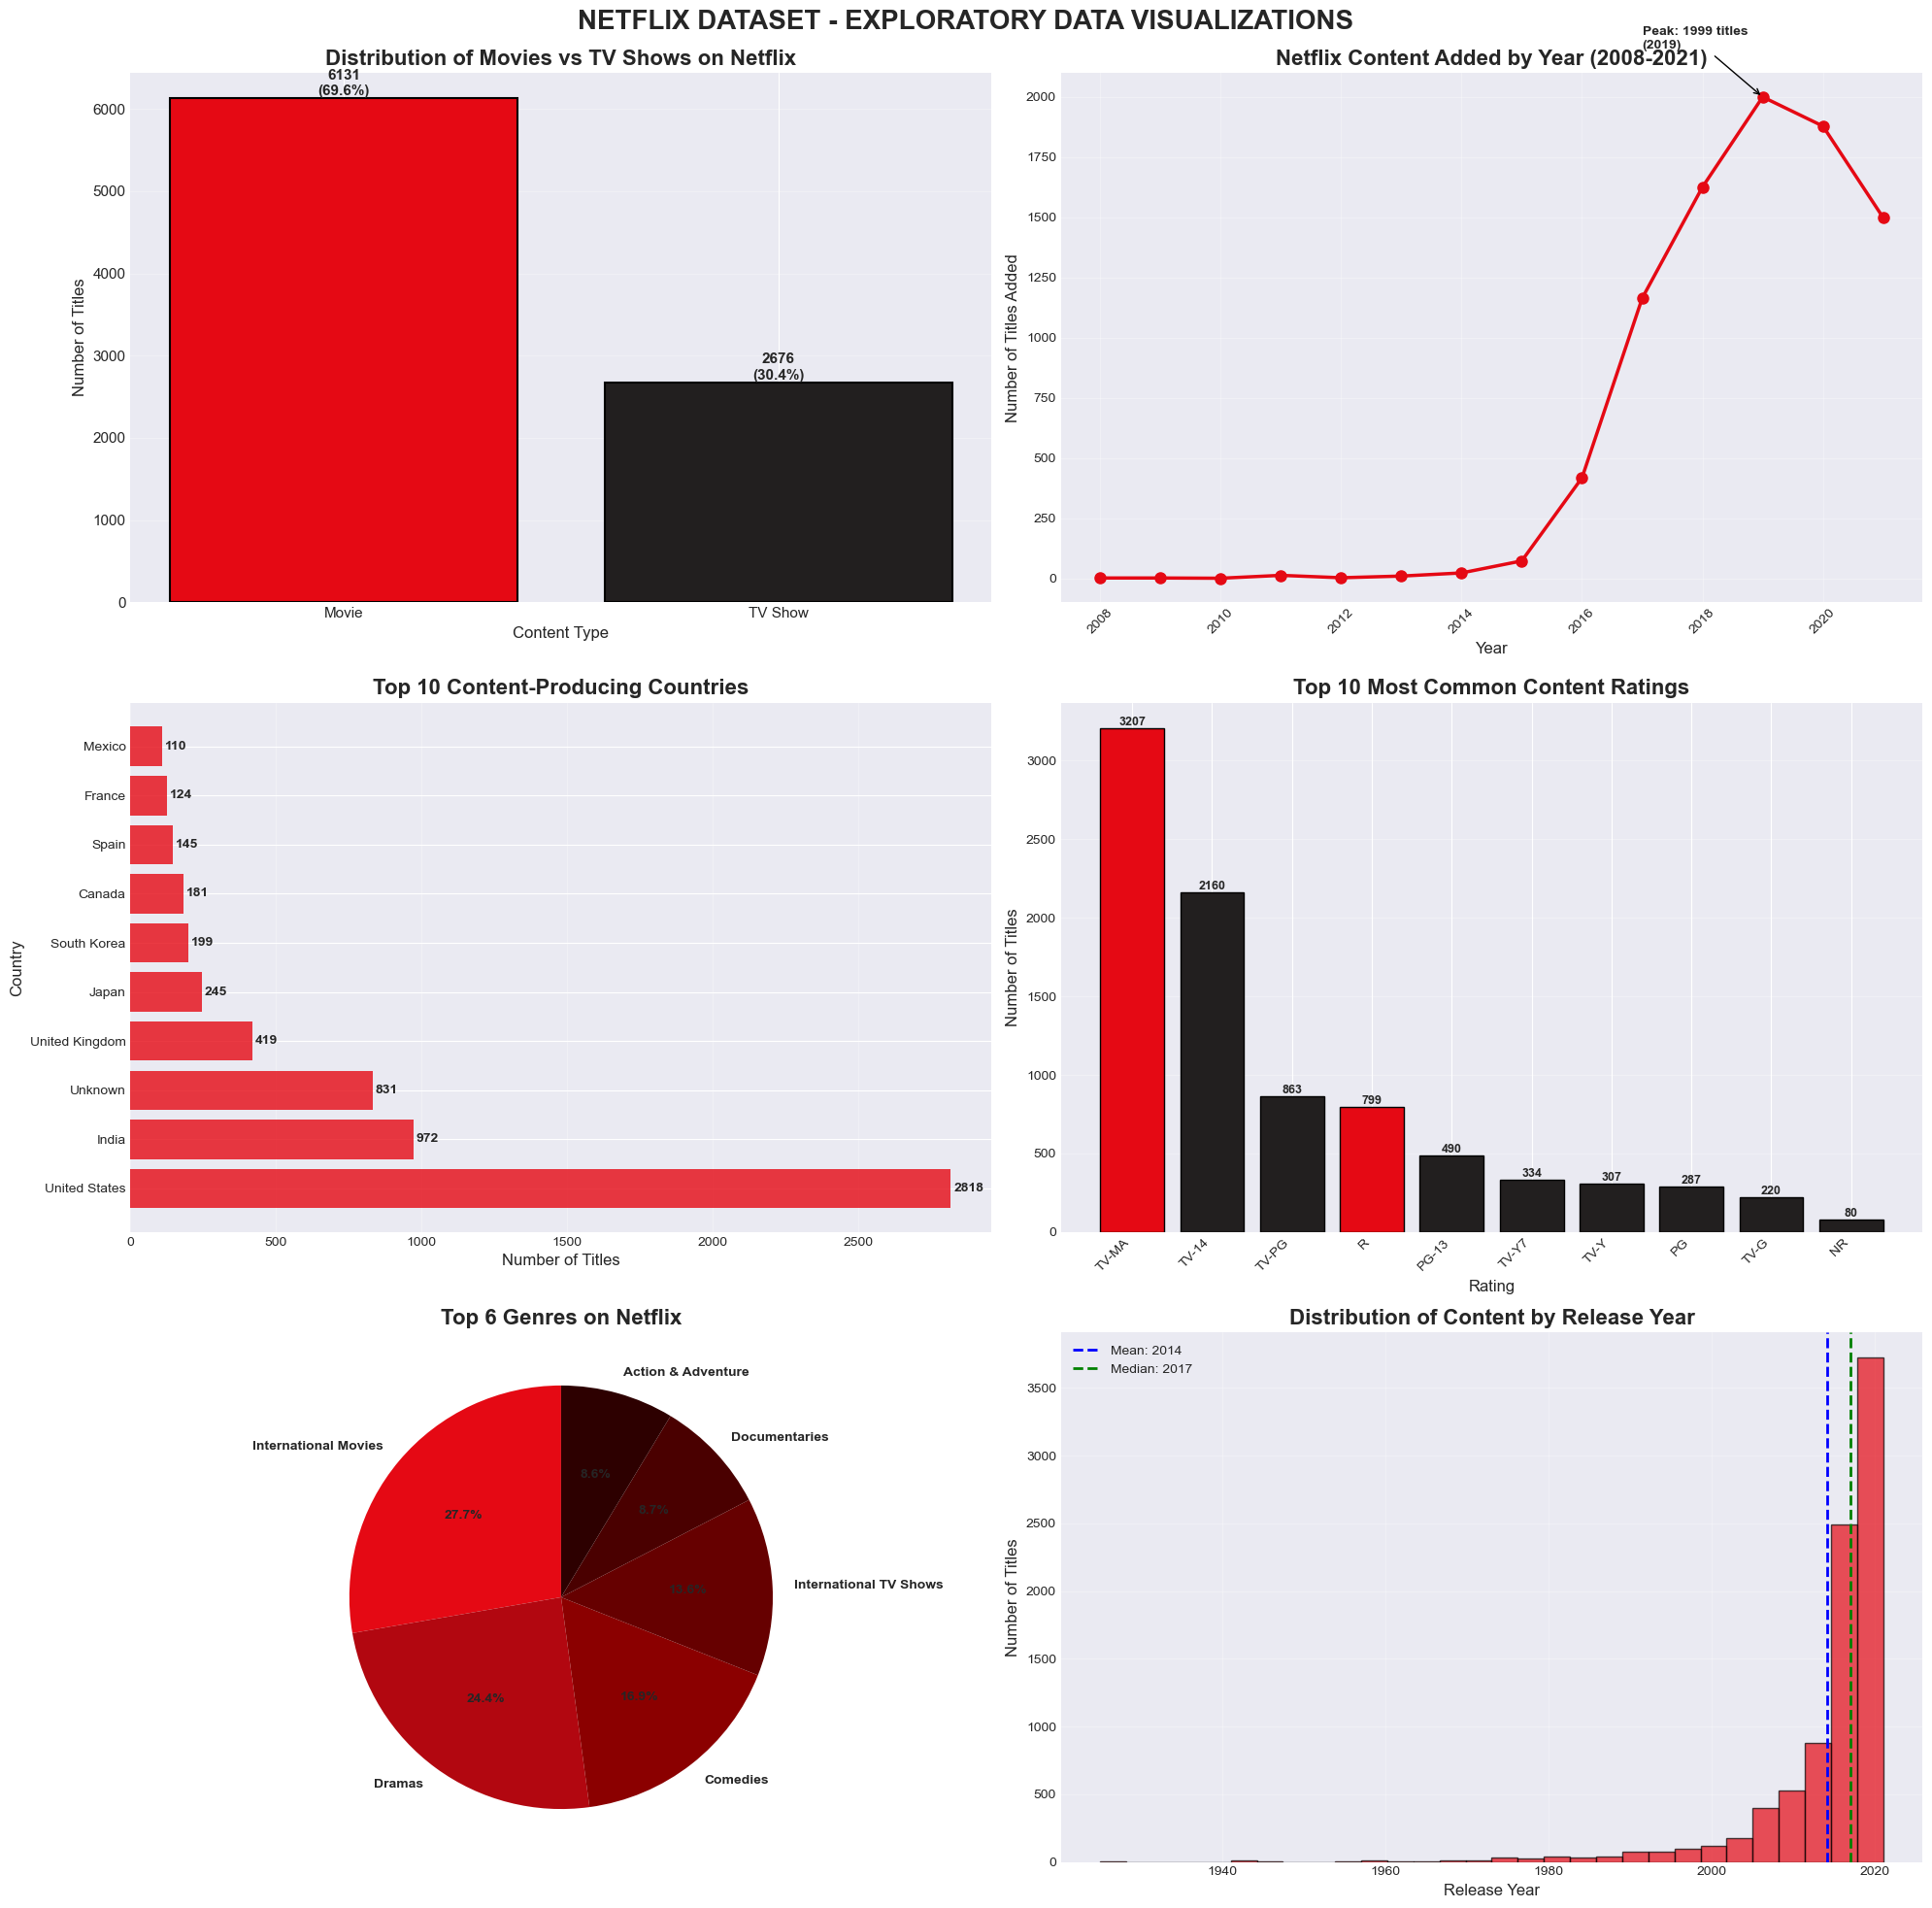

In [13]:
# Set up visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Create a figure with subplots
fig = plt.figure(figsize=(20, 20))

# 1. BAR CHART: Movies vs TV Shows Distribution
plt.subplot(3, 2, 1)
type_counts = netflix_clean['type'].value_counts()
colors = ['#E50914', '#221F1F']  # Netflix colors
bars = plt.bar(type_counts.index, type_counts.values, color=colors, edgecolor='black', linewidth=1.5)
plt.title('Distribution of Movies vs TV Shows on Netflix', fontsize=16, fontweight='bold')
plt.xlabel('Content Type', fontsize=12)
plt.ylabel('Number of Titles', fontsize=12)
# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}\n({height/len(netflix_clean)*100:.1f}%)',
             ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

# 2. LINE CHART: Content Added by Year
plt.subplot(3, 2, 2)
yearly_data = netflix_clean['add_year'].value_counts().sort_index()
years = yearly_data.index.astype(int)
counts = yearly_data.values
plt.plot(years, counts, marker='o', linewidth=2.5, markersize=8, color='#E50914')
plt.title('Netflix Content Added by Year (2008-2021)', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Titles Added', fontsize=12)
plt.xticks(years[::2], rotation=45)
plt.grid(True, alpha=0.3)
# Add trend annotation
max_year = years[np.argmax(counts)]
max_count = max(counts)
plt.annotate(f'Peak: {max_count} titles\n({max_year})', 
             xy=(max_year, max_count), 
             xytext=(max_year-2, max_count+200),
             arrowprops=dict(arrowstyle='->', color='black'),
             fontsize=10, fontweight='bold')

# 3. BAR CHART: Top 10 Content-Producing Countries
plt.subplot(3, 2, 3)
top_countries = netflix_clean['country'].value_counts().head(10)
bars = plt.barh(top_countries.index, top_countries.values, color='#E50914', alpha=0.8)
plt.title('Top 10 Content-Producing Countries', fontsize=16, fontweight='bold')
plt.xlabel('Number of Titles', fontsize=12)
plt.ylabel('Country', fontsize=12)
# Add value labels
for bar in bars:
    width = bar.get_width()
    plt.text(width + 10, bar.get_y() + bar.get_height()/2,
             f'{int(width)}', ha='left', va='center', fontsize=10, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()

# 4. BAR CHART: Top 10 Most Common Ratings
plt.subplot(3, 2, 4)
top_ratings = netflix_clean['rating'].value_counts().head(10)
colors_rating = ['#E50914' if r in ['TV-MA', 'R'] else '#221F1F' for r in top_ratings.index]
bars = plt.bar(top_ratings.index, top_ratings.values, color=colors_rating, edgecolor='black', linewidth=1)
plt.title('Top 10 Most Common Content Ratings', fontsize=16, fontweight='bold')
plt.xlabel('Rating', fontsize=12)
plt.ylabel('Number of Titles', fontsize=12)
plt.xticks(rotation=45, ha='right')
# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}', ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

# 5. PIE CHART: Top 6 Genres
plt.subplot(3, 2, 5)
# Split genres and get top 6
all_genres = []
for genres in netflix_clean['listed_in']:
    if isinstance(genres, str):
        all_genres.extend([g.strip() for g in genres.split(',')])
genre_counts = pd.Series(all_genres).value_counts().head(6)
colors_genre = ['#E50914', '#B20710', '#8B0000', '#660000', '#4A0000', '#2D0000']
plt.pie(genre_counts.values, labels=genre_counts.index, autopct='%1.1f%%',
        colors=colors_genre, startangle=90, textprops={'fontsize': 10, 'fontweight': 'bold'})
plt.title('Top 6 Genres on Netflix', fontsize=16, fontweight='bold')

# 6. HISTOGRAM: Release Year Distribution
plt.subplot(3, 2, 6)
plt.hist(netflix_clean['release_year'], bins=30, color='#E50914', alpha=0.7, edgecolor='black', linewidth=1)
plt.title('Distribution of Content by Release Year', fontsize=16, fontweight='bold')
plt.xlabel('Release Year', fontsize=12)
plt.ylabel('Number of Titles', fontsize=12)
plt.axvline(netflix_clean['release_year'].mean(), color='blue', linestyle='dashed', 
            linewidth=2, label=f'Mean: {netflix_clean["release_year"].mean():.0f}')
plt.axvline(netflix_clean['release_year'].median(), color='green', linestyle='dashed', 
            linewidth=2, label=f'Median: {netflix_clean["release_year"].median():.0f}')
plt.legend()
plt.grid(alpha=0.3)

plt.suptitle('NETFLIX DATASET - EXPLORATORY DATA VISUALIZATIONS', fontsize=20, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

##Task 5: Insights - Netflix Dataset


In [14]:
print("="*60)
print("NETFLIX DATASET - COMPLETE ANALYSIS SUMMARY")
print("="*60)

print("\n" + "🔍 KEY INSIGHTS FOUND:")
print("-"*60)

insights = [
    {
        "insight": "Netflix's library is heavily movie-focused",
        "finding": "Movies make up 69.6% (6,131 titles) vs TV Shows at 30.4% (2,676 titles)",
        "implication": "Netflix primarily targets viewers who prefer movies over series"
    },
    {
        "insight": "Content addition peaked in 2019 with 1,999 new titles",
        "finding": "Steady growth from 2015-2019, with slight decline in 2020-2021",
        "implication": "Netflix's aggressive expansion strategy peaked in 2019"
    },
    {
        "insight": "United States dominates content production (32% of total)",
        "finding": "US: 2,818 titles, India: 972 titles, UK: 419 titles",
        "implication": "Significant opportunity for international content expansion"
    },
    {
        "insight": "Mature content (TV-MA/TV-14) dominates Netflix's library",
        "finding": "TV-MA: 36.4%, TV-14: 24.5% - combined 60.9% of all titles",
        "implication": "Netflix primarily targets adult audiences"
    },
    {
        "insight": "International content and Dramas are the most common genres",
        "finding": "International Movies: 2,752, Dramas: 2,427, Comedies: 1,674",
        "implication": "Netflix invests heavily in international and drama content"
    }
]

for i, item in enumerate(insights, 1):
    print(f"\n{i}. {item['insight']}")
    print(f"   📊 Finding: {item['finding']}")
    print(f"   💡 Implication: {item['implication']}")

print("\n" + "="*60)
print("✅ NETFLIX DATASET ANALYSIS COMPLETE")
print("="*60)
print(f"\n📁 Dataset: Netflix Movies & TV Shows")
print(f"📊 Total Records: 8,807")
print(f"📋 Total Features: 12 (plus engineered features)")
print(f"🎯 Analysis Date: {pd.Timestamp.now().strftime('%Y-%m-%d')}")

NETFLIX DATASET - COMPLETE ANALYSIS SUMMARY

🔍 KEY INSIGHTS FOUND:
------------------------------------------------------------

1. Netflix's library is heavily movie-focused
   📊 Finding: Movies make up 69.6% (6,131 titles) vs TV Shows at 30.4% (2,676 titles)
   💡 Implication: Netflix primarily targets viewers who prefer movies over series

2. Content addition peaked in 2019 with 1,999 new titles
   📊 Finding: Steady growth from 2015-2019, with slight decline in 2020-2021
   💡 Implication: Netflix's aggressive expansion strategy peaked in 2019

3. United States dominates content production (32% of total)
   📊 Finding: US: 2,818 titles, India: 972 titles, UK: 419 titles
   💡 Implication: Significant opportunity for international content expansion

4. Mature content (TV-MA/TV-14) dominates Netflix's library
   📊 Finding: TV-MA: 36.4%, TV-14: 24.5% - combined 60.9% of all titles
   💡 Implication: Netflix primarily targets adult audiences

5. International content and Dramas are the most 